# Click-Through Rate Prediction on the Avazu Dataset

## Data Loading

In [1]:
import sys
from zipfile import ZipFile
import os.path as op
try:
    from urllib.request import urlretrieve
except ImportError:
    from urllib import urlretrieve

AVAZU_URL = "https://bianchi.wp.imt.fr/files/2019/05/train-1000000.zip"
AVAZU_FILENAME = AVAZU_URL.rsplit('/', 1)[1]

if not op.exists(AVAZU_FILENAME):
    print('Downloading %s to %s...' % (AVAZU_URL, AVAZU_FILENAME))
    urlretrieve(AVAZU_URL, AVAZU_FILENAME)
    print('Extracting to %s...' % AVAZU_FILENAME)
    ZipFile(AVAZU_FILENAME).extractall('.')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## Exploratory Data Analysis

In [3]:
df = pd.read_csv('train-1000000')
print(df.shape)
df.head()

(1000000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,3.983206e+18,0,14102915,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,2,4687,320,50,423,2,39,100148,32
1,7.756884e+18,0,14103007,1002,0,cb809abf,74acf31a,50e219e0,ecad2386,7801e8d9,...,0,0,17894,320,50,2039,2,39,100077,32
2,6.941774e+17,0,14102711,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,22684,320,50,2619,1,163,100055,71
3,2.664154e+18,1,14102903,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221
4,1.480510e+19,0,14102902,1005,1,791b5571,fd13bc73,f028772b,ecad2386,7801e8d9,...,1,0,8330,320,50,761,3,175,100081,23


In [4]:
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,9.226511e+18,0.169971,1.410256e+07,1004.968549,0.288466,1.015506,0.332436,18835.759473,318.888112,60.030918,2111.794488,1.432802,226.940103,53163.356361,83.404070
std,5.322835e+18,0.375608,2.966148e+02,1.096112,0.505974,0.527867,0.856103,4966.228494,21.279475,47.174174,610.393836,1.325815,350.944666,49960.216178,70.326773
min,1.003272e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.000000,20.000000,112.000000,0.000000,33.000000,-1.000000,1.000000
25%,4.613978e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.000000,50.000000,1863.000000,0.000000,35.000000,-1.000000,23.000000
50%,9.238351e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.000000,50.000000,2323.000000,2.000000,39.000000,100048.000000,61.000000
75%,1.384023e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21894.000000,320.000000,50.000000,2526.000000,3.000000,171.000000,100088.000000,101.000000
max,1.844670e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.000000,1024.000000,2757.000000,3.000000,1839.000000,100248.000000,255.000000


### Target Distribution

In [5]:
print(df['click'].value_counts())

click
0    830029
1    169971
Name: count, dtype: int64


We find that the dataset is imbalanced, therefore accuracy won't be a good measure of our models, we'll preferr log loss and ROC-AUC score

### Feature Cardinality

In [6]:
categorical_features = []
for column in df.columns :
    value = df[column][0]
    if type(value) not in [np.float64, np.int64]:
        categorical_features.append(column)

categorical_df = df[categorical_features]
categorical_df.nunique()

site_id            2651
site_domain        2871
site_category        22
app_id             3157
app_domain          198
app_category         26
device_id        150501
device_ip        555248
device_model       5168
dtype: int64

We find that we have multiple categorical features with an important amount of unique values. Naively encoding everything doesn't seem like it will be the most optimal solution.

### Temporal Feature Engineering

The hour column encodes date and hour in format YYMMDDHH. We extract the actual hour of day and weekday.

In [7]:
import datetime

def datesplit(originalDate):
    originalDate = str(originalDate)
    year  = int("20" + originalDate[0:2])
    month = int(originalDate[2:4])
    day   = int(originalDate[4:6])
    hour  = int(originalDate[6:8])
    return datetime.datetime(year, month, day, hour)

dt = datesplit(14102915)
print(dt)

2014-10-29 15:00:00


The weekday and the hour are much more important than the actual date so we'll create a new feature containg the weekday and update the hour feature

In [8]:
df['weekday'] = df['hour'].apply(lambda x: datesplit(x).weekday())
df['hour']    = df['hour'].apply(lambda x: datesplit(x).hour)

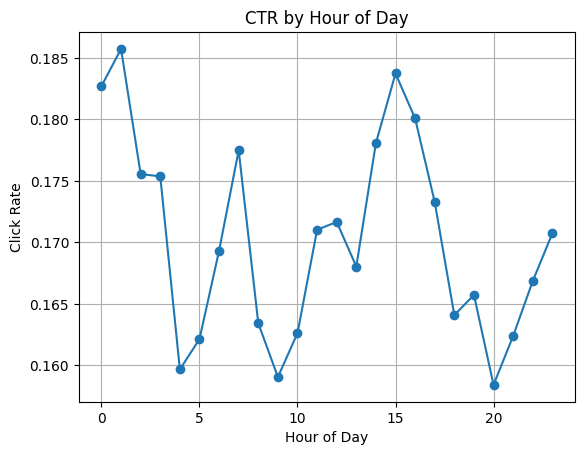

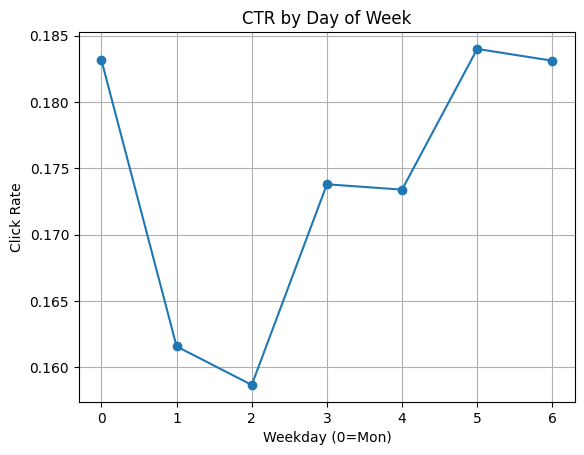

In [9]:
ctr_by_hour = df.groupby('hour')['click'].mean()
ctr_by_hour.plot(marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Click Rate')
plt.title('CTR by Hour of Day')
plt.grid(True)
plt.show()

ctr_by_day = df.groupby('weekday')['click'].mean()
ctr_by_day.plot(marker='o')
plt.xlabel('Weekday (0=Mon)')
plt.ylabel('Click Rate')
plt.title('CTR by Day of Week')
plt.grid(True)
plt.show()

CTR has a clear hourly pattern — lower at night, peaking during daytime hours. This confirms that temporal features are predictive and worth keeping.

## Feature Engineering

### User Identifier

The `device_id` column has one dominant value (anonymous/unknown devices). For these, we construct a proxy user ID from `device_ip + device_model`.

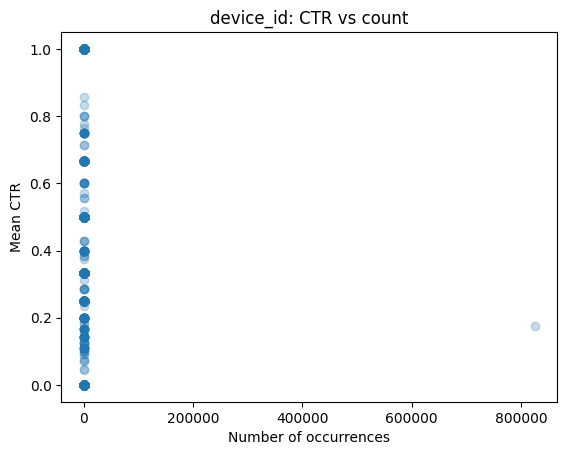

In [10]:
summary = df.groupby('device_id')['click'].agg(['mean', 'count'])
summary.columns = ['mean_ctr', 'n_val']

plt.scatter(summary['n_val'], summary['mean_ctr'], alpha=0.25)
plt.xlabel('Number of occurrences')
plt.ylabel('Mean CTR')
plt.title('device_id: CTR vs count')
plt.show()

We see that there is one device id that dominates and is much more frequent than the rest

In [11]:
most_common_device = df['device_id'].value_counts().index[0]
most_common_count  = df['device_id'].value_counts().values[0]

print("Most common device_id:", most_common_device)
print("It appears", most_common_count, "times : this is the unknown device bucket.")

Most common device_id: a99f214a
It appears 824918 times : this is the unknown device bucket.


We'll create a new user feature that represents the device_id for known devices and contains device_ip + device_model for unknown devices. Then we remove device_id, device_model, device_ip given that we don't need them anymore.

In [12]:
df['user'] = None

mask_anonymous = df['device_id'] == most_common_device
df.loc[mask_anonymous, 'user'] = df.loc[mask_anonymous, 'device_ip'] + df.loc[mask_anonymous, 'device_model']

mask_known = df['device_id'] != most_common_device
df.loc[mask_known, 'user'] = df.loc[mask_known, 'device_id']

df.drop(columns=['device_id', 'device_model', 'device_ip'], inplace=True)

### Site Feature Consolidation

The features site_id and site_domain carry correlated information so w'll concatenate them

In [13]:
df['site'] = df['site_id'] + df['site_domain']
df.drop(columns=['site_id', 'site_domain'], inplace=True)

In [14]:
df.columns

Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'site_category', 'app_id',
       'app_domain', 'app_category', 'device_type', 'device_conn_type', 'C14',
       'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'weekday', 'user',
       'site'],
      dtype='object')

## Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

features = [c for c in df.columns if c not in ['id', 'click']]
X = df[features]
y = df['click']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.1, random_state=100
)

## Baseline — Logistic Regression on Reduced Feature Set

First thing just to get an idea, we'll put features with high cardinality to the side for now and we'll only keep categorical features with a small amount of unique values then we will encode them + the non-categorical features. 

In [16]:
from sklearn.preprocessing import OneHotEncoder

some_columns = ['hour', 'weekday', 'C1', 'banner_pos', 'site_category',
                'app_category', 'device_type', 'device_conn_type',
                'C15', 'C16', 'C18', 'C21']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
Xtrain_oh = ohe.fit_transform(Xtrain[some_columns])
Xtest_oh  = ohe.transform(Xtest[some_columns])

print("The new number of features :", Xtrain_oh.shape[1])

The new number of features : 183


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

lr_reduced = LogisticRegression()
lr_reduced.fit(Xtrain_oh, ytrain)

hard_pred_reduced = lr_reduced.predict(Xtest_oh)
soft_pred_reduced = lr_reduced.predict_proba(Xtest_oh)[:, 1]

acc = accuracy_score(ytest, hard_pred_reduced)
logloss = log_loss(ytest, soft_pred_reduced)
auc = roc_auc_score(ytest, soft_pred_reduced)

print(f"Accuracy:  {acc:.4f}")
print(f"Log Loss:  {logloss:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

Accuracy:  0.8305
Log Loss:  0.4252
ROC-AUC:   0.6761


We see that accuracy is good but that does'nt really mean anything due to class imbalance, even a completely naive predictor that returns 0 for everybody will get the same accuracy.

However the Log Loss and ROC-AUC indicate that the model is closer to completely random guessing than to an optimal predictor.

There is still work to be done.

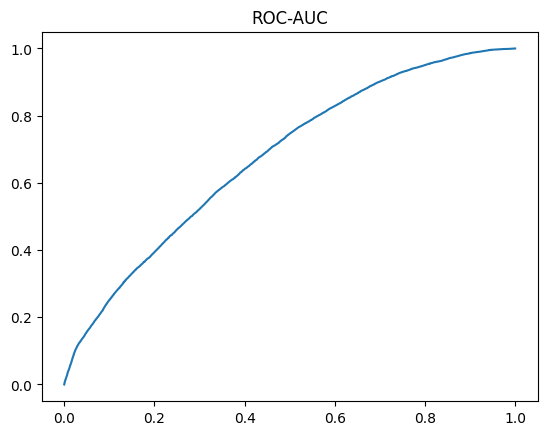

In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(ytest, soft_pred_reduced)

plt.plot(fpr, tpr)
plt.title("ROC-AUC")
plt.show()

## Full Feature Logistic Regression

Now we use all features that we will encode, however to not get 700 000 features, we'll only keep columns seen more than 100 times in the training test

In [19]:
ohe_full = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
Xtrain_oh_full = ohe_full.fit_transform(Xtrain)
Xtest_oh_full  = ohe_full.transform(Xtest)

print(f"Full OHE dimension: {Xtrain_oh_full.shape[1]:,}")

Full OHE dimension: 713,334


In [20]:
n_ones = np.array(Xtrain_oh_full.sum(axis=0)).flatten()
useful = n_ones > 100
cols_to_keep = [i for i, b in enumerate(useful) if b]

print(f"Total OHE features:           {Xtrain_oh_full.shape[1]:,}")
print(f"Features dropped:      {Xtrain_oh_full.shape[1] - len(cols_to_keep):,}")
print(f"Features seen > 100 times to keep:    {len(cols_to_keep):,}")


Total OHE features:           713,334
Features dropped:      711,363
Features seen > 100 times to keep:    1,971


We will only keep 1971 features, which is much better than 713 334

In [21]:
lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(Xtrain_oh_full[:, cols_to_keep], ytrain)

soft_full = lr_full.predict_proba(Xtest_oh_full[:, cols_to_keep])[:, 1]
print(f"Log Loss: {log_loss(ytest, soft_full):.4f}")
print(f"ROC-AUC:  {roc_auc_score(ytest, soft_full):.4f}")

Log Loss: 0.4015
ROC-AUC:  0.7380


ROC-AUC of 0.738 is a good improvement over the reduced baseline, confirming that the high-cardinality features carry real signal. 

Log loss of 0.40 reflects the limits of a linear model, it can't capture feature interactions

This is why we'll start exploring other non-linear models

## Gradient Boosting + LR Stacking

A powerful technique: use a GBM to transform the input into leaf indices, then train a logistic regression on these new features. Trees capture non-linear interactions; LR provides calibrated probabilities.

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.8,
    max_depth=3,
    verbose=1
)
gb.fit(Xtrain_oh_full[:, cols_to_keep], ytrain)

      Iter       Train Loss   Remaining Time 
         1           0.8743            2.50m
         2           0.8646            2.37m
         3           0.8583            2.23m
         4           0.8535            2.12m
         5           0.8503            2.08m
         6           0.8464            2.04m
         7           0.8441            1.97m
         8           0.8418            1.90m
         9           0.8404            1.86m
        10           0.8383            1.81m
        20           0.8282            1.30m
        30           0.8234           52.00s
        40           0.8190           29.55s
        50           0.8163            0.00s


,loss,'log_loss'
,learning_rate,0.8
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [23]:
soft_gb = gb.predict_proba(Xtest_oh_full[:, cols_to_keep])[:, 1]
print(f"Log Loss: {log_loss(ytest, soft_gb):.4f}, ROC-AUC: {roc_auc_score(ytest, soft_gb):.4f}")

Log Loss: 0.4092, ROC-AUC: 0.7252


The log loss and ROC AUC are no better than with Logistic reression alone but we're still going to add Logistic regression on the stacked features

In [24]:
print(f"gb.estimators_ shape: ({len(gb.estimators_)}, {len(gb.estimators_[0])})")
print(f"Type of each estimator: {type(gb.estimators_[0][0])}")

gb.estimators_ shape: (50, 1)
Type of each estimator: <class 'sklearn.tree._classes.DecisionTreeRegressor'>


Here gb.estimatos is a list of Decision Tree Regressors. Each DecisionTreeRegressor in this list represents a weak learner that has been fitted to the residuals of the previous learners in the boosting process.

Now we're going to extract the leaf indices from the trained gradient boost and one-hot encode them to use as new features for the logistic regression.

In [25]:
from scipy.sparse import hstack

leafs_train = pd.DataFrame(gb.apply(Xtrain_oh_full[:, cols_to_keep])[:, :, 0])
leafs_test  = pd.DataFrame(gb.apply(Xtest_oh_full[:, cols_to_keep])[:, :, 0])

print(f"Leaf features shape : {leafs_train.shape}")

ohe_leafs = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
leafs_train_oh = ohe_leafs.fit_transform(leafs_train)
leafs_test_oh  = ohe_leafs.transform(leafs_test)

print(f"OHE leaf features shape : {leafs_train_oh.shape}")

Leaf features shape : (900000, 50)
OHE leaf features shape : (900000, 397)


The 50 trees produced 397 binary leaf features. 

We now concatenate these with the original OHE features and train the final logistic regression on the enriched matrix.

In [26]:
from scipy.sparse import csr_matrix

Xtrain_concat = hstack([Xtrain_oh_full[:, cols_to_keep], leafs_train_oh])
Xtest_concat  = hstack([Xtest_oh_full[:, cols_to_keep],  leafs_test_oh])

lr_stacked = LogisticRegression(max_iter=1000)
lr_stacked.fit(Xtrain_concat, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
soft_stacked = lr_stacked.predict_proba(Xtest_concat)[:, 1]
print(f"Log Loss: {log_loss(ytest, soft_stacked):.4f}, ROC-AUC: {roc_auc_score(ytest, soft_stacked):.4f}")

Log Loss: 0.4001, ROC-AUC: 0.7416


Marginal improvement over standalone LR (0.738 → 0.741 AUC), which makes sense, we only used 50 shallow tree (max_depth = 3), so the leaf features don't capture dramatically richer interactions than the original OHE.

We hop the gain will be more significant with XGBoost using more estimators.

## XGBoost

In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=50,
    learning_rate=0.8,
    n_jobs=-1,
    verbosity=1,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(Xtrain_oh_full[:, cols_to_keep], ytrain)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:30:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [29]:
soft_xgb = xgb.predict_proba(Xtest_oh_full[:, cols_to_keep])[:, 1]
print(f"Log Loss: {log_loss(ytest, soft_xgb):.4f}, ROC-AUC: {roc_auc_score(ytest, soft_xgb):.4f}")

Log Loss: 0.4044, ROC-AUC: 0.7342


In [30]:
xgb_256 = XGBClassifier(
    n_estimators=256,
    learning_rate=0.8,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_256.fit(Xtrain_oh_full[:, cols_to_keep], ytrain)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:30:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [31]:
soft_xgb_256 = xgb_256.predict_proba(Xtest_oh_full[:, cols_to_keep])[:, 1]
print(f"Log Loss: {log_loss(ytest, soft_xgb_256):.4f}, ROC-AUC: {roc_auc_score(ytest, soft_xgb_256):.4f}")

Log Loss: 0.4020, ROC-AUC: 0.7390


We get the same log loss and ROC-AUC as the previous model but the computation is much faster with XGBoost

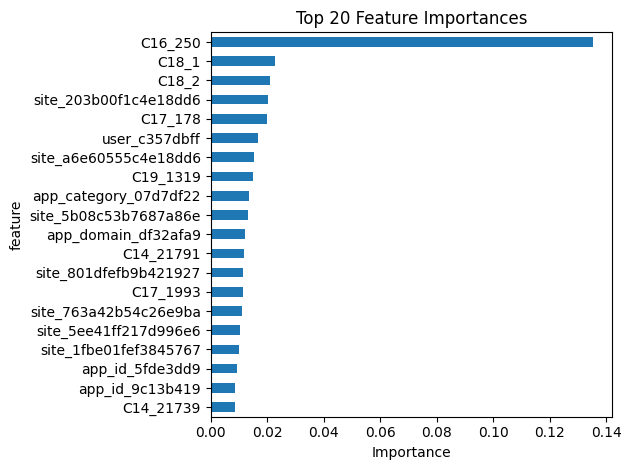

In [35]:
import pandas as pd

importances = xgb_256.feature_importances_

feature_names = ohe_full.get_feature_names_out()
feature_names_kept = feature_names[cols_to_keep]

fi = pd.DataFrame({'feature': feature_names_kept, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(20)

fi.plot(kind='barh', x='feature', y='importance', legend=False)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

We see that one type of the C16 feature dominates, this shows that there is a specific category of the feature C16 (anonymous so can't know what it means) that makes people click a lot more than anything else.

## Results Summary

In [43]:
results = {
    'LR (reduced OHE)':      (log_loss(ytest, soft_pred_reduced), roc_auc_score(ytest, soft_pred_reduced)),
    'LR (full OHE)':         (log_loss(ytest, soft_full),         roc_auc_score(ytest, soft_full)),
    'GB (50 trees)':         (log_loss(ytest, soft_gb),           roc_auc_score(ytest, soft_gb)),
    'GB + LR (stacked)':     (log_loss(ytest, soft_stacked),      roc_auc_score(ytest, soft_stacked)),
    'XGBoost (50 trees)':    (log_loss(ytest, soft_xgb),          roc_auc_score(ytest, soft_xgb)),
    'XGBoost (256 trees)':   (log_loss(ytest, soft_xgb_256),      roc_auc_score(ytest, soft_xgb_256)),
}

df_results = pd.DataFrame(results, index=['Log Loss ↓', 'ROC-AUC ↑']).T
df_results = df_results.sort_values('ROC-AUC ↑', ascending=False)

print("=" * 55)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(df_results.to_string(float_format='%.4f'))
print("=" * 55)

MODEL PERFORMANCE SUMMARY
                     Log Loss ↓  ROC-AUC ↑
GB + LR (stacked)        0.4001     0.7416
XGBoost (256 trees)      0.4020     0.7390
LR (full OHE)            0.4015     0.7380
XGBoost (50 trees)       0.4044     0.7342
GB (50 trees)            0.4092     0.7252
LR (reduced OHE)         0.4252     0.6761


## Online Learning

In production, CTR models need to update in real time as new click/no-click events arrive. You cannot retrain a full model from scratch every time. Online learning solves this by updating the model one batch at a time using partial_fit(), without ever seeing the full dataset at once.

This simulates a streaming pipeline where data arrives in chunks of 10,000 rows.

SGD with log loss represents logistic regression. here partial_fit gets called multiple times and at each time it performs gradient descent but it's starting point is the point it left at the last time, so every time it recieves a new batch it fits on it.

In [44]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='log_loss', random_state=42)

chunk_size = 10000
n_samples = Xtrain_oh_full.shape[0]

for start in range(0, n_samples, chunk_size):
    end = start + chunk_size
    X_chunk = Xtrain_oh_full[start:end][:, cols_to_keep]
    y_chunk = ytrain.iloc[start:end]
    sgd.partial_fit(X_chunk, y_chunk, classes=[0, 1])

In [45]:
soft_sgd = sgd.predict_proba(Xtest_oh_full[:, cols_to_keep])[:, 1]
print(f'Log Loss: {log_loss(ytest, soft_sgd):.4f}, ROC-AUC: {roc_auc_score(ytest, soft_sgd):.4f}')

Log Loss: 0.4087, ROC-AUC: 0.7261


The online model performs comparably to the full logistic regression despite never seeing the entire dataset at once. In a real system, partial_fit() would be called each time a new batch of impression/click events arrives, keeping the model up to date with shifting user behaviour.

## Optimal Bidding Strategy

In online advertising, when an ad slot opens there happens an auction about who gets the slot, in order to choose our bid we have to know what are the chances of getting a click.

Therefore, to choose wether or not to bid or how much, we need to connect the model output to expected revenue.

The logic is : our model predicts a CTR for each impression, and given the value of a click (for example we gain 2 euros per click), the expected value of an impression = CTR x value_per_click

Thus we should only bid if the expected value exceeds our bid price

In [51]:
value_per_click = 2.0

predicted_ctr = soft_xgb_256

expected_value = predicted_ctr * value_per_click

min_bid = 0.15
should_bid = expected_value > min_bid

bid_amount = expected_value * should_bid

print(f'Total impressions:        {len(should_bid):,}')
print(f'Impressions to bid on:    {should_bid.sum():,}')
print(f'Average bid on selected:  €{bid_amount[should_bid].mean():.4f}')
print(f'Max bid:                  €{bid_amount.max():.4f}')
print(f'Min bid:                  €{bid_amount[should_bid].min():.4f}')

Total impressions:        100,000
Impressions to bid on:    70,057
Average bid on selected:  €0.4528
Max bid:                  €1.9883
Min bid:                  €0.1500


In [52]:
actual_clicks_in_bid = ytest[should_bid].sum()
total_bids = should_bid.sum()

precision_on_bids = actual_clicks_in_bid / total_bids
print(f'Click rate on bid impressions: {precision_on_bids:.4f} ({precision_on_bids*100:.2f}%)')
print(f'vs global click rate:          {ytest.mean():.4f} ({ytest.mean()*100:.2f}%)')
print(f'Our model selects impressions {precision_on_bids/ytest.mean():.1f}x more likely to be clicked than random.')

Click rate on bid impressions: 0.2251 (22.51%)
vs global click rate:          0.1700 (17.00%)
Our model selects impressions 1.3x more likely to be clicked than random.


By bidding only on high expected-value impressions, we significantly increase the click rate compared to random bidding. 